In [3]:
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN
from tensorflow.keras.datasets import imdb

In [17]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

In [18]:
X_test

array([[   0,    0,    0, ...,   14,    6,  717],
       [   6,  976, 2078, ...,  125,    4, 3077],
       [   4, 5673,    7, ...,    9,   57,  975],
       ...,
       [   0,    0,    0, ...,   21,  846, 5518],
       [   0,    1,   11, ..., 2302,    7,  470],
       [  56,   96,  346, ...,   34, 2005, 2643]],
      shape=(25000, 100), dtype=int32)

In [19]:
model = Sequential([
    Embedding(10000, 32, input_length=100),
    SimpleRNN(5, return_sequences=True),
    SimpleRNN(7, return_sequences=True),
    SimpleRNN(10),
    Dense(1, activation='sigmoid')
])

f:\Learning\DL\Learning\Deep-Learning\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam', metrics=['accuracy'], loss='binary_crossentropy')

In [23]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5764 - loss: 0.6601 - val_accuracy: 0.6668 - val_loss: 0.6184
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7386 - loss: 0.5335 - val_accuracy: 0.7172 - val_loss: 0.5565
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8166 - loss: 0.4109 - val_accuracy: 0.8114 - val_loss: 0.4394
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8765 - loss: 0.3050 - val_accuracy: 0.7888 - val_loss: 0.4913
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9162 - loss: 0.2229 - val_accuracy: 0.7972 - val_loss: 0.5283


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 100, 32)          │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (32, 100, 5)           │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (32, 100, 7)           │            91 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (32, 10)               │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 1)                │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,418 (3.67 MB)

 Trainable params: 320,472 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 640,946 (2.45 MB)

In [25]:
y_pred = model.predict(X_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


In [35]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [27]:
import matplotlib.pyplot as plt

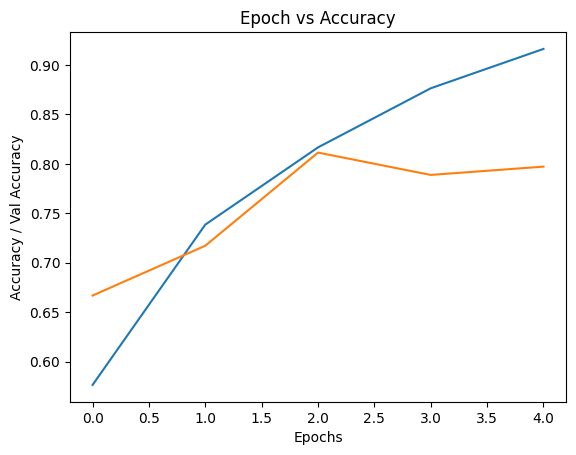

In [49]:
plt.title('Epoch vs Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy / Val Accuracy')
plt.plot(history.epoch, history.history['accuracy'])
plt.plot(history.epoch, history.history['val_accuracy'])
plt.show()

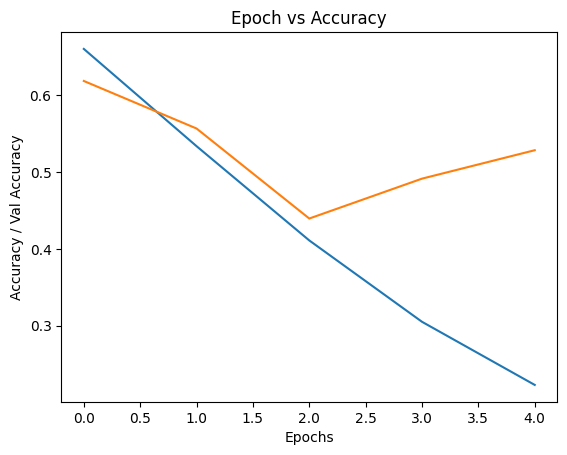

In [50]:
plt.title('Epoch vs Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy / Val Accuracy')
plt.plot(history.epoch, history.history['loss'])
plt.plot(history.epoch, history.history['val_loss'])
plt.show()